In [43]:
import torch
from datasets import load_dataset
import os
from transformers import AutoTokenizer
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from transformers import AutoModelForSequenceClassification
from transformers import TrainingArguments
from transformers import Trainer
from evaluate import load
import pandas as pd
import matplotlib.pyplot as plt


In [44]:
data_path = "/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/data/test_read_training_data_right_classifications/paragraph_and_sentence_len_5_min_chunk_len_100_cos_thresh_0.4_nace_level_1_stoxx"
data_path = "/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/data/training_data/dataset__reports_subset_from_full_data_1_sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_1__sample_ratio_1__filter_only_right_chunks"

In [45]:
from datasets import DatasetDict, Dataset

# Load a custom CSV file
data_files = {"train": os.path.join(data_path, "train_data.csv"), "test": os.path.join(data_path, "test_data.csv"), "validation": os.path.join(data_path, "val_data.csv")}
# Load the CSV files using pandas
train_df = pd.read_csv(data_files["train"])
test_df = pd.read_csv(data_files["test"])
validation_df = pd.read_csv(data_files["validation"])

train_df = train_df[(train_df["NACE_Code"] == "D") | (train_df["NACE_Code"] == "B")]
test_df = test_df[(test_df["NACE_Code"] == "D") | (test_df["NACE_Code"] == "B")]
validation_df = validation_df[(validation_df["NACE_Code"] == "D") | (validation_df["NACE_Code"] == "B")]

# Convert pandas DataFrames to Hugging Face Dataset
dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df),
    "test": Dataset.from_pandas(test_df),
    "validation": Dataset.from_pandas(validation_df)
})
label_mapping = {char: val for val, char in enumerate(['A','B','C','D','E','F','G','H','I','J','K','L','M','N','O','P','Q','R','S','T','U'])}
dataset = dataset.map(lambda x: {"label": label_mapping[x["NACE_Code"]]})

print(dataset["train"][0])

Map:   0%|          | 0/2405 [00:00<?, ? examples/s]

Map:   0%|          | 0/826 [00:00<?, ? examples/s]

Map:   0%|          | 0/769 [00:00<?, ? examples/s]

{'Evaluation': None, 'Notes': None, 'text': 'table summarizes historical estimates within the meaning of ni . the source of the estimates is section of pfs as repeated in tr. the historical estimates set forth in table do not use categories of mineral resources other than the ones set out in the cim definition standards and section of ni . for further details on the parameters utilized in the estimates the reader is referred to section of pfs.', 'Score': 0.4780528428045011, 'NACE_Code': 'B', '__index_level_0__': 16, 'label': 1}


In [46]:
train_df

,Evaluation,Notes,text,Score,NACE_Code
16,NaN,NaN,table summarizes historical estimates within t...,0.478053,B
18,NaN,NaN,the miningrelated modifying factors applied in...,0.505435,B
20,NaN,NaN,the group also holds various professional trai...,0.564445,B
29,NaN,NaN,all the electric power activities are develope...,0.502310,D
42,NaN,NaN,december in millions distribution transmission...,0.516569,D
...,...,...,...,...,...
17505,NaN,NaN,on october ratchaburi electricity generating c...,0.504941,D
17511,NaN,NaN,sdg enel chile commitments ensure access to af...,0.478666,D
17513,NaN,NaN,artisanal and smallscale gold mining asgm refe...,0.478687,B
17523,NaN,NaN,this mror statement has been compiled and repo...,0.564562,B


In [47]:
train_df["NACE_Code"].value_counts()

NACE_Code
B    1221
D    1184
Name: count, dtype: int64

In [48]:
dataset["train"]

Dataset({
    features: ['Evaluation', 'Notes', 'text', 'Score', 'NACE_Code', '__index_level_0__', 'label'],
    num_rows: 2405
})

In [49]:
# Initialize the BERT tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Tokenize a sample text
sample_text = dataset["train"][0]["text"]
tokens = tokenizer(sample_text, padding="max_length", truncation=True, max_length=128)

print(tokens)


{'input_ids': [101, 2795, 7680, 7849, 10057, 3439, 10035, 2306, 1996, 3574, 1997, 9152, 1012, 1996, 3120, 1997, 1996, 10035, 2003, 2930, 1997, 1052, 10343, 2004, 5567, 1999, 19817, 1012, 1996, 3439, 10035, 2275, 5743, 1999, 2795, 2079, 2025, 2224, 7236, 1997, 9754, 4219, 2060, 2084, 1996, 3924, 2275, 2041, 1999, 1996, 25022, 2213, 6210, 4781, 1998, 2930, 1997, 9152, 1012, 2005, 2582, 4751, 2006, 1996, 11709, 12550, 1999, 1996, 10035, 1996, 8068, 2003, 3615, 2000, 2930, 1997, 1052, 10343, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [50]:
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

# Apply the tokenizer to the dataset
tokenized_datasets = dataset.map(tokenize_function, batched=True)

# Inspect tokenized samples
print(tokenized_datasets["train"][0])

Map:   0%|          | 0/2405 [00:00<?, ? examples/s]

Map:   0%|          | 0/826 [00:00<?, ? examples/s]

Map:   0%|          | 0/769 [00:00<?, ? examples/s]

{'Evaluation': None, 'Notes': None, 'text': 'table summarizes historical estimates within the meaning of ni . the source of the estimates is section of pfs as repeated in tr. the historical estimates set forth in table do not use categories of mineral resources other than the ones set out in the cim definition standards and section of ni . for further details on the parameters utilized in the estimates the reader is referred to section of pfs.', 'Score': 0.4780528428045011, 'NACE_Code': 'B', '__index_level_0__': 16, 'label': 1, 'input_ids': [101, 2795, 7680, 7849, 10057, 3439, 10035, 2306, 1996, 3574, 1997, 9152, 1012, 1996, 3120, 1997, 1996, 10035, 2003, 2930, 1997, 1052, 10343, 2004, 5567, 1999, 19817, 1012, 1996, 3439, 10035, 2275, 5743, 1999, 2795, 2079, 2025, 2224, 7236, 1997, 9754, 4219, 2060, 2084, 1996, 3924, 2275, 2041, 1999, 1996, 25022, 2213, 6210, 4781, 1998, 2930, 1997, 9152, 1012, 2005, 2582, 4751, 2006, 1996, 11709, 12550, 1999, 1996, 10035, 1996, 8068, 2003, 3615, 2000,

In [51]:
labels = dataset["train"]["label"]
class_weights = compute_class_weight("balanced", classes=np.unique(labels), y=labels)
print(class_weights)

[0.98484848 1.015625  ]


In [52]:
# Initialize a BERT model for binary classification
model_name = "bert-base-uncased"
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(set(labels)))

print(model.config)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertConfig {
  "_attn_implementation_autoset": true,
  "_name_or_path": "bert-base-uncased",
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "torch_dtype": "float32",
  "transformers_version": "4.49.0",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}



In [53]:
for param in model.bert.parameters():
    param.requires_grad = False
    #param.requires_grad = True # Train the model as well!

# Keep only the classification head trainable
for param in model.classifier.parameters():
    param.requires_grad = True

print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")


Trainable parameters: 1538


In [ ]:
# Define training arguments
training_args = TrainingArguments(
    output_dir="./results",           # Directory for saving model checkpoints
    evaluation_strategy="epoch",     # Evaluate at the end of each epoch
    learning_rate=5e-5,              # Start with a small learning rate
    per_device_train_batch_size=16,  # Batch size per GPU
    per_device_eval_batch_size=16,
    use_mps_device=True,               # <— key switch
    num_train_epochs=30,              # Number of epochs
    weight_decay=0.01,               # Regularization
    save_total_limit=2,              # Limit checkpoints to save space
    load_best_model_at_end=True,     # Automatically load the best checkpoint
    logging_dir="./logs",            # Directory for logs
    logging_steps=100,               # Log every 100 steps
    #fp16=True,                      # Enable mixed precision for faster training
    save_strategy="epoch"
)

#print(training_args)


/Users/hendrikweichel/miniconda3/envs/remedi/lib/python3.10/site-packages/transformers/training_args.py:1594: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/Users/hendrikweichel/miniconda3/envs/remedi/lib/python3.10/site-packages/transformers/training_args.py:2262: UserWarning: `use_mps_device` is deprecated and will be removed in version 5.0 of 🤗 Transformers. `mps` device will be used by default if available similar to the way `cuda` device is used.Therefore, no action from user is required. 
  warnings.warn(


In [55]:
# Load a metric (F1-score in this case)
metric = load("f1")

# Define a custom compute_metrics function
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=-1)
    return metric.compute(predictions=predictions, references=labels, average="weighted")

In [56]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
data_collator

DataCollatorWithPadding(tokenizer=BertTokenizerFast(name_or_path='bert-base-uncased', vocab_size=30522, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
), padding=True, max_length=None, pad_to_multiple_of=None, return_tensors='pt')

In [57]:
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")

In [58]:
import torch
import torch.nn as nn
from transformers import Trainer

class WeightedCELossTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = (
            torch.as_tensor(class_weights, dtype=torch.float32) if class_weights is not None else None
        )

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs["labels"]                 # shape [B], dtype long
        outputs = model(**{k: v for k, v in inputs.items() if k != "labels"})
        logits  = outputs.logits                  # [B, C]
        loss_fn = nn.CrossEntropyLoss(
            weight=self.class_weights.to(logits.device) if self.class_weights is not None else None
        )
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

In [59]:
trainer = WeightedCELossTrainer(
    model=model,                        # Pre-trained BERT model
    args=training_args,                 # Training arguments
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    tokenizer=tokenizer,
    data_collator=data_collator,        # Efficient batching
    class_weights=class_weights,   # <— here’s A
    compute_metrics=compute_metrics     # Custom metric
)

/var/folders/fp/yhl61lbj3m73x3_17tsp1vrr0000gn/T/ipykernel_39808/2231333852.py:7: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedCELossTrainer.__init__`. Use `processing_class` instead.
  super().__init__(*args, **kwargs)


In [ ]:
# Start trainingO
trainer.train()

/Users/hendrikweichel/miniconda3/envs/remedi/lib/python3.10/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss


In [ ]:
# Evaluate the model
results = trainer.evaluate()
print(results)

{'eval_loss': nan, 'eval_f1': 0.34568666641300483}


In [ ]:
# Tokenize the input text
input_text = "HI"
inputs = tokenizer(input_text, return_tensors="pt")

# Move inputs to the appropriate device
inputs = {key: value.to(device) for key, value in inputs.items()}

# Perform inference
model.to(device)
with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits

print(logits)

# Get the predicted label
predicted_label = torch.argmax(logits, dim=-1).item()
print("Predicted label:", predicted_label)

tensor([[-1.5939,  1.5302]], device='mps:0')
Predicted label: 1


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Generate predictions
predictions = trainer.predict(tokenized_datasets["test"])
predicted_labels = predictions.predictions.argmax(axis=-1)

# Classification report
print(classification_report(tokenized_datasets["test"]["label"], predicted_labels))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.47      1.00      0.64       386
           3       0.00      0.00      0.00       440

    accuracy                           0.47       826
   macro avg       0.16      0.33      0.21       826
weighted avg       0.22      0.47      0.30       826



/Users/hendrikweichel/miniconda3/envs/remedi/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/hendrikweichel/miniconda3/envs/remedi/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/hendrikweichel/miniconda3/envs/remedi/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,

ValueError: The number of FixedLocator locations (3), usually from a call to set_ticks, does not match the number of labels (21).

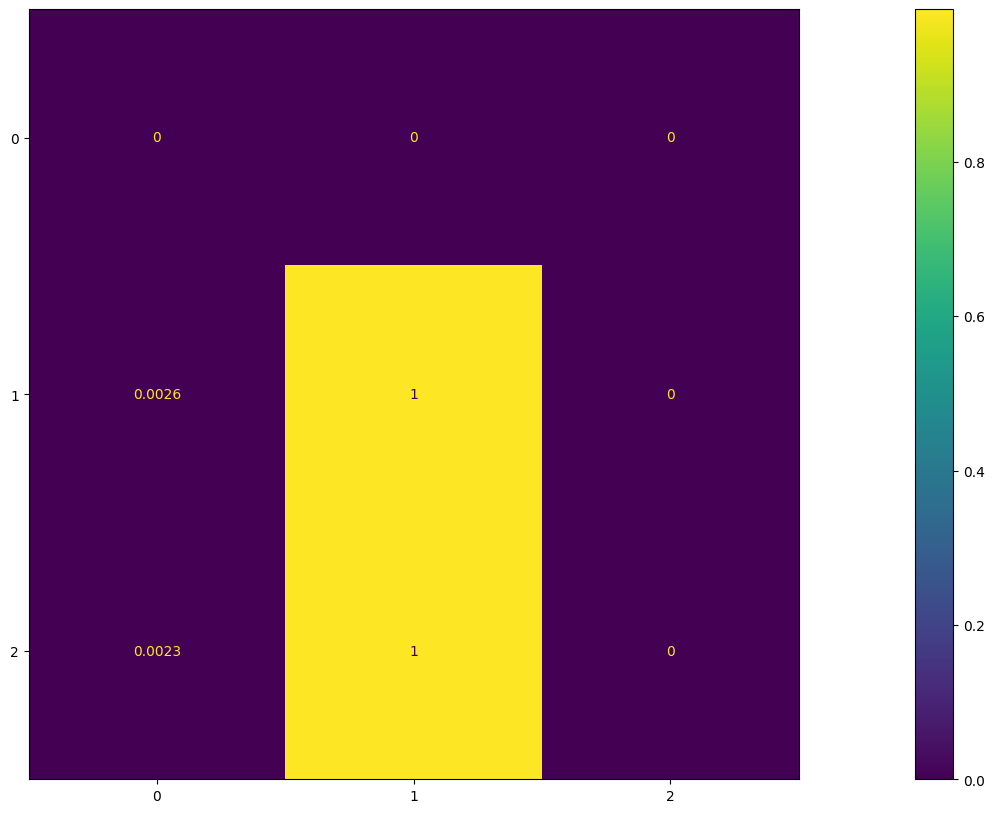

In [ ]:
# Confusion matrix
cm = confusion_matrix(tokenized_datasets["test"]["label"], predicted_labels, normalize="true")
alphabet = "ABCDEFGHIJKLMNOPQRSTUVW"
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f"Label_{alphabet[i]}" for i in range(0, 21)])
fig, ax = plt.subplots(figsize=(30, 10))  # <-- set size here
disp.plot(ax=ax, xticks_rotation="vertical")
plt.show()

In [ ]:
ckpt = "results/checkpoint-5668"
final_dir = "my_model_final"  

model = AutoModelForSequenceClassification.from_pretrained(ckpt)
tokenizer = AutoTokenizer.from_pretrained(ckpt)

# model.save_pretrained(final_dir)         # writes config + model.safetensors (or pytorch_model.bin)
# tokenizer.save_pretrained(final_dir)     # writes tokenizer files

In [ ]:
sentenec = "all manufacturing of secondary aluminium is defined by the taxonomy as making a substantial contribution to climate change mitigation. to be a taxonomyaligned activity the manufacture of secondary aluminium must also comply with the dnsh criteria for manufacture of aluminium and hydro must comply with the criteria for processes and outcomes related to human rights bribery and corruption taxation and fair competition minimum safeguards."
sentenec = "all manufacturing of secondary aluminium is defined by the taxonomy as making a substantial contribution to climate change mitigation. to be a taxonomyaligned activity the manufacture of secondary aluminium must also comply with the dnsh criteria for manufacture of aluminium and hydro must comply with the criteria for processes and outcomes related to human rights bribery and corruption taxation and fair competition minimum safeguards."
sentenec = "i. regasification basic and secondary transmission as well as storage of natural gas via the corresponding gas infrastructure or facilities of its own or of third parties and also the performance of auxiliary activities or others related to the aforementioned activities."
inputs = tokenizer(sentenec, return_tensors="pt")
with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits
    predictions = torch.argmax(logits, dim=-1)

In [ ]:
# If you set id2label in config earlier, you can get human-readable labels
label = model.config.id2label[predictions.item()]
print("Predicted label:", label)

Predicted label: LABEL_10
